# Поиск наилучшего узла

Узлов: 5514 Ребер: 12199
Расчет узлов


426923808 7.355415617070702


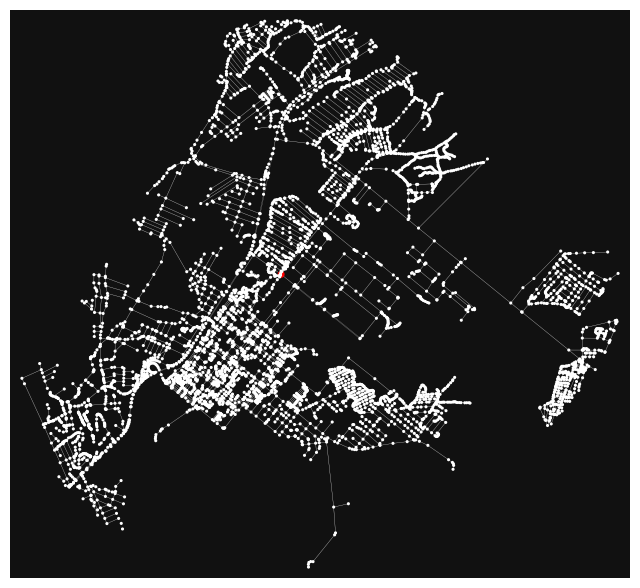

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl


G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

print('Расчет узлов')
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val = Graphs.get_best_node_full(G, 
                          node_metric_function=calc_node_metric_function
                          )
print(best_node, best_val)

nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 5 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

## Расчет времени прибытия в каждый из узлов

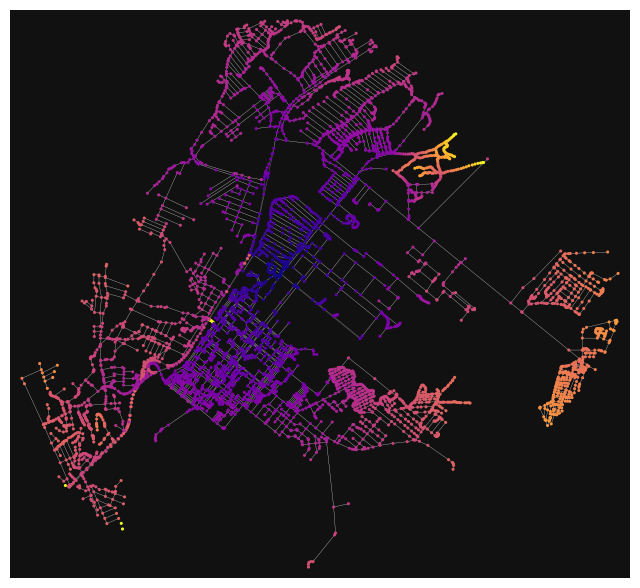

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
lens = ssfpl(G, best_node, weight = 'travel_time')
mval = max(lens.values())
lens_full = {node:lens[node] if node in lens else mval for node in G.nodes()}

nx.set_node_attributes(G, lens_full, 'route_time')
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=5)

## Расчет метрик во всех узлах

In [3]:
route_time_mean = {}
route_time_max = {}
nodes_ip5 = {}

i=0
for node in G.nodes():
    print(f'{i}/{G.number_of_nodes():<5}', end='\r')
    route_time_mean[node] = metric_by_time(G, 
                    path_function=msfpl,
                    metric_function=np.mean,
                    err_val=15)(node)
    route_time_max[node] = metric_by_time(G, 
                    path_function=msfpl, 
                    metric_function=np.max,
                    err_val=20)(node)
    nodes_ip5[node] = metric_by_time(G, 
                    path_function=msfpl, 
                    metric_function=cover_index(ip_val=5),
                    err_val=0)(node)
    i+=1

# Установка значений
nx.set_node_attributes(G, route_time_mean, 'route_time_mean')
nx.set_node_attributes(G, route_time_max, 'route_time_max')
nx.set_node_attributes(G, nodes_ip5, 'nodes_ip5')

# Печать карты со средними значениями
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time_mean", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

# Печать карты с максимальными значениями
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time_max", cmap="viridis")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

# Печать карты с значениями ИП-5
nc = ox.plot.get_node_colors_by_attr(G, attr="nodes_ip5", cmap="viridis")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

KeyboardInterrupt: 

## Поиск наилучшего узла из некоторого множества

In [ ]:
nodes = list(G.nodes())
nodes_set = [nodes[50], nodes[200], nodes[500], nodes[1000], nodes[1500], nodes[3000], nodes[4000]]
print(nodes_set)
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val = Graphs.get_best_node_full(G, 
                          node_metric_function=calc_node_metric_function,
                          possible_nodes=nodes_set
                          )
print("лучший узел", best_node, best_val)

print('метрики для каждого из узлов:')
for node in nodes_set:
    m = calc_node_metric_function(node)
    print(node, m)

[426923800, 1526100295, 1555148534, 2034401706, 2034402276, 2760591335, 4901942432]
лучший узел 1555148534 7.822793333848111
метрики для каждого из узлов:
426923800 8.878949760719477
1526100295 13.983186482246678
1555148534 7.822793333848111
2034401706 8.44882116476329
2034402276 11.341234937136626
2760591335 10.595102796316963
4901942432 11.515153311552636


## Расчет лучшего узла алгоритмом стока

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl

import random
# import logging as lg
# lg.basicConfig(level=lg.DEBUG)

G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


426923808 7.355415617070702


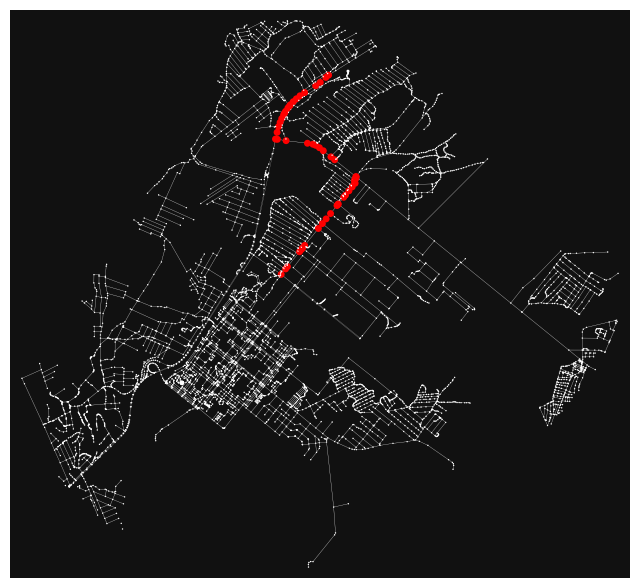

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# lg.basicConfig(level=lg.DEBUG)
# lg.basicConfig(level=lg.ERROR)
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val, route = Graphs.get_best_node_drain(G, 
                          node_metric_function=calc_node_metric_function
                          )
# lg.basicConfig(level=lg.ERROR)

print(best_node, best_val)
nc = ['r' if nd in route else 'w' for nd in G.nodes()]
ns = [25 if nd in route else 1 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

In [ ]:
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val, route = Graphs.get_best_node_drain(G, 
                          node_metric_function=calc_node_metric_function,
                          all_nodes=True
                          )

print(best_node, best_val)
# nc = ['r' if nd in route else 'w' for nd in G.nodes()]
# ns = [25 if nd in route else 5 for nd in G.nodes()]
# ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

426923808 7.355415617070702


## Расчет метрикой max_time+mean_time

In [2]:
def get_best_node_drain_mm(G, start_node=None):
    '''
    Это в калькуляторы

    Minimum travel time location problem - MTTLP
    '''
    calc_node_metric_function = metric_by_time(G,
                                path_function=msfpl,
                                metric_function=np.max,
                                )
    best_node, best_val, _ = Graphs.get_best_node_drain(G, 
                            node_metric_function=calc_node_metric_function,
                            start_node=start_node
                            )

    calc_node_metric_function = metric_by_time(G,
                                path_function=msfpl,
                                metric_function=np.mean,
                                )
    best_node, best_val, _ = Graphs.get_best_node_drain(G, 
                            node_metric_function=calc_node_metric_function,
                            start_node=best_node
                            )
    return best_node, best_val


print('Без стартового узла:', get_best_node_drain_mm(G))
node = 2712076294
print('Со стартовым узлом', get_best_node_drain_mm(G, node))

Без стартового узла: (426923808, 7.355415617070702)


Со стартовым узлом (426923808, 7.355415617070702)


С использованием функции из `algorithms.Graphs`

In [3]:
# Оценка для неизвестного стартового узла
cur_node, cur_val = Graphs.get_best_node_drain_max_mean(G, path_function=msfpl)
print('Оценка для неизвестного стартового узла', cur_node, cur_val)

# Оценка для известного стартового узла
cur_node, cur_val = Graphs.get_best_node_drain_max_mean(G, path_function=msfpl, start_node=list(G.nodes())[300])
print('Оценка для известного стартового узла', cur_node, cur_val)

Оценка для неизвестного стартового узла 426923808 7.355415617070702


TypeError: metric_by_time() got an unexpected keyword argument 'start_node'

### Расчет для нескольких узлов последовательно

С использованием функции из `algorithms.Graphs`

Расчет узла 2054468666
426923808 7.355415617070702
Расчет узла 4796091623
426923808 7.355415617070702
Расчет узла 4796070861
426923808 7.355415617070702
Расчет узла 2054468644
426923808 7.355415617070702
Расчет узла 2042076517
426923808 7.355415617070702
Расчет узла 9994288430
426923808 7.355415617070702
Расчет узла 2034401348
426923808 7.355415617070702
Расчет узла 9060052053
426923808 7.355415617070702
Расчет узла 3119947227
426923808 7.355415617070702
Расчет узла 4116052097
426923808 7.355415617070702
Расчет узла 2054469016
426923808 7.355415617070702
Расчет узла 2034402813
426923808 7.355415617070702
Расчет узла 4336348792
426923808 7.355415617070702
Расчет узла 2054468689
426923808 7.355415617070702
Расчет узла 2054469188
426923808 7.355415617070702
Расчет узла 3981428902
426923808 7.355415617070702
Расчет узла 3981463644
426923808 7.355415617070702
Расчет узла 4796070876
426923808 7.355415617070702
Расчет узла 4796091618
426923808 7.355415617070702
Расчет узла 2932152230
42692380

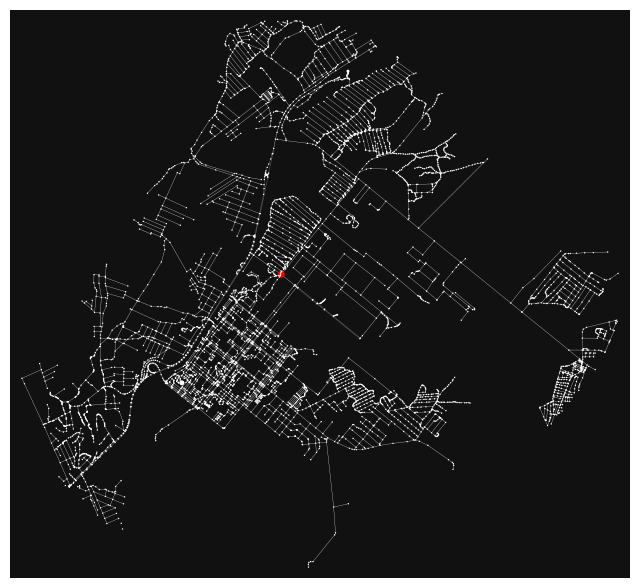

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
sample_size = 10
start_nodes = random.sample(list(G.nodes()), sample_size)
start_nodes

best_val = 1000
best_node
for node in start_nodes:
    print('Расчет узла', node)
    try:
        cur_node, cur_val = Graphs.get_best_node_drain_max_mean(G, node)
        print(cur_node, cur_val)
    except ValueError:
        print(f'Узел {node} неприемлем')                               
    if cur_val<best_val:
        best_val = cur_val
        best_node = cur_node

print(best_node, best_val)

nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 1 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

# Расчет ячеек Вороного

In [ ]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl

import random
# import logging as lg
# lg.basicConfig(level=lg.DEBUG)

G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

In [ ]:
nodes_list = list(G.nodes())
centers = [nodes_list[20], nodes_list[200]]
print('центры', centers)
voronoi = nx.voronoi_cells(G, centers, weight='travel_time')
voronoi
# тупиковый путь - так как все-равно нужно добавлять функционал обрезки по границам

# Тесты

In [ ]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import calc_node_metric, cover_index
from genesis.swiss_knife import msfpl, ssfpl


In [ ]:
def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

G = create_G()
nodes_list=[2,5,8]
best_node, best_val = Graphs.get_best_node_full(G,
                        path_function=msfpl,
                        metric_function=np.mean,
                        possible_nodes=nodes_list,
                        appr_val=0.5
                        )
print(best_node, best_val)

print('метрики для каждого из узлов:')
for node in nodes_list:
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=np.mean,
                     appr_val=0.5,
                     err_val=0)
                    #  err_val='pass')
    print(node, m)

2 8.69
метрики для каждого из узлов:
2 8.69
5 0
8 0


In [ ]:
best_node, best_val = Graphs.get_best_node_full(G,
                            path_function=msfpl,
                            metric_function=cover_index(),
                            # appr_val=0,
                            reduce=False
                            )
print(best_node, best_val)

1 66.67


In [ ]:
print('метрики для каждого из узлов:')
for node in G.nodes():
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=cover_index(),
                    #  err_val=0)
                     err_val='pass')
    print(node, m)

метрики для каждого из узлов:
1 66.67
2 61.54
3 69.23
4 64.29
5 83.33
6 85.71
7 71.43
8 75.0
9 100.0
10 100.0
11 75.0
12 100.0
13 100.0
14 100.0
15 100.0


In [ ]:
print('метрики для каждого из узлов:')
for node in G.nodes():
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=cover_index(),
                     appr_val=0.5,
                     err_val=0)
                    #  err_val='pass')
    print(node, m)

метрики для каждого из узлов:
1 66.67
2 61.54
3 69.23
4 64.29
5 0
6 85.71
7 71.43
8 0
9 0
10 0
11 0
12 0
13 0
14 0
15 0


In [ ]:
print('метрики для каждого из узлов:')
for node in G.nodes():
    m = calc_node_metric(G,
                     node,
                     path_function=msfpl,
                     metric_function=cover_index(),
                     appr_val=1,
                        )
                    # err_val=0)
                    #  err_val='pass')
    print(node, m)

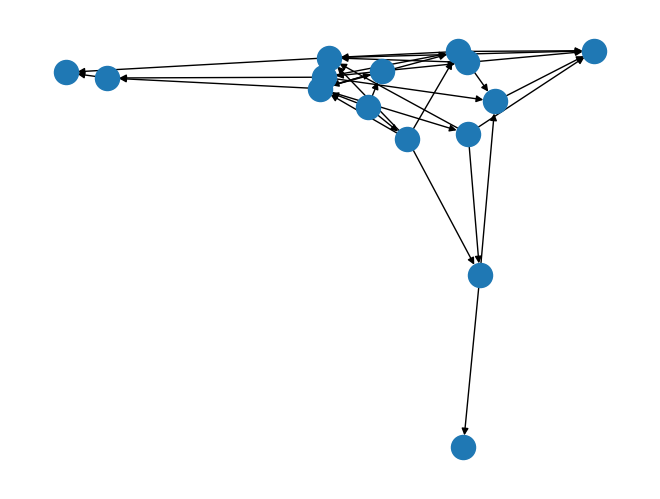

In [ ]:
nx.draw(G, pos=nx.spring_layout(G))

In [ ]:
pn = None
bn = list(G.nodes())[0]
bn==pn

False

In [ ]:
def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

G = create_G()

In [ ]:
for edge in G.in_edges(2):
    print(edge[0])

1
3


In [ ]:
for edge in G.out_edges(2):
    print(edge[1])

3
5
6


In [ ]:
G.add_edge(1, 2, key=0, travel_time=3)
G.add_edge(3, 2, key=0, travel_time=3)
G.add_edge(2, 3, key=0, travel_time=2)
G.add_edge(2, 5, key=0, travel_time=5)
G.add_edge(2, 6, key=0, travel_time=7)

In [ ]:
G[3]

AdjacencyView({2: {0: {'travel_time': 3}}, 7: {0: {'travel_time': 3}}, 8: {0: {'travel_time': 4}}, 9: {0: {'travel_time': 5}}})